In [1]:
# Imports
import os
import copy
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_fscore_support
)

In [2]:
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
# Dataset paths
DATASETS = {
    "JAFFE": {
        "train": "/content/drive/MyDrive/JAFFE-[70,30]/train",
        "test":  "/content/drive/MyDrive/JAFFE-[70,30]/test"
    },
    "CK": {
        "train": "/content/drive/MyDrive/CK+/train",
        "test":  "/content/drive/MyDrive/CK+/test"
    }
}

In [6]:
# Class names
CLASS_NAMES = ["angry", "fear", "happy", "neutral", "sad", "surprise"]

# Map folder names to standard class names (handles naming differences between datasets)
LABEL_MAP = {
    "angry": "angry",
    "fear": "fear",
    "happy": "happy",
    "neutral": "neutral",
    "sad": "sad",
    "surprise": "surprise",
    "anger": "angry",
    "happiness": "happy",
    "sadness": "sad"
}

In [7]:
# Load Haar cascade for face detection
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def detect_and_crop_face(img_bgr):
    # Convert to greyscale for detection
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) > 0:
        # Select the largest detected face
        x, y, w, h = max(faces, key=lambda b: b[2] * b[3])
        face = img_bgr[y:y+h, x:x+w]
        detected = True
    else:
        # If no face is detected, use full image
        face = img_bgr
        detected = False

    return face, detected

In [8]:
# Training transforms: resize, augmentation, normalise using ImageNet stats
effnet_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# Evaluation transforms: resize and normalise only (no augmentation)
effnet_eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

In [9]:
# Supported image file types
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

# Dataset class
class FERDataset(Dataset):
    def __init__(self, root_dir, transform=None, log_detection=False):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        self.failed_detections = 0
        self.total_images = 0
        self.log_detection = log_detection

        # Load image paths and labels from folder structure
        for folder in sorted(os.listdir(root_dir)):
            folder_path = os.path.join(root_dir, folder)

            if not os.path.isdir(folder_path):
                continue

            folder_lower = folder.lower().strip()

            if folder_lower not in LABEL_MAP:
                continue

            canonical_label = LABEL_MAP[folder_lower]
            label_idx = CLASS_NAMES.index(canonical_label)

            for file_name in os.listdir(folder_path):
                if file_name.lower().endswith(IMG_EXTENSIONS):
                    img_path = os.path.join(folder_path, file_name)
                    self.samples.append((img_path, label_idx))

        print(f"\nLoaded {len(self.samples)} images from {root_dir}")

        label_counts = Counter([label for _, label in self.samples])
        print("Label counts:")
        for idx in sorted(label_counts.keys()):
            print(f"{CLASS_NAMES[idx]}: {label_counts[idx]}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            raise ValueError(f"Could not read image: {img_path}")

        # Detect and crop face region
        face_bgr, detected = detect_and_crop_face(img_bgr)

        if self.log_detection:
            self.total_images += 1
            if not detected:
                self.failed_detections += 1

        # Convert BGR to RGB then to PIL for transforms
        face_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(face_rgb)

        if self.transform:
            img_pil = self.transform(img_pil)

        return img_pil, label

    def print_detection_stats(self):
        if self.total_images == 0:
            print("No detection stats collected.")
            return

        rate = (self.failed_detections / self.total_images) * 100
        print(f"Face detection failure rate: {rate:.2f}% ({self.failed_detections}/{self.total_images})")

In [10]:
# Create train and test datasets and data loaders
def get_dataloaders(dataset_name, batch_size=16):
    train_dir = DATASETS[dataset_name]["train"]
    test_dir = DATASETS[dataset_name]["test"]

    train_dataset = FERDataset(train_dir, transform=effnet_train_transform)
    test_dataset = FERDataset(test_dir, transform=effnet_eval_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

    return train_dataset, test_dataset, train_loader, test_loader

In [11]:
# Class weights
def compute_class_weights(dataset):
    labels = [label for _, label in dataset.samples]
    counts = Counter(labels)
    total = sum(counts.values())

    weights = []
    for class_idx in range(len(CLASS_NAMES)):
        count = counts.get(class_idx, 1)
        weights.append(total / (len(CLASS_NAMES) * count))

    weights = torch.tensor(weights, dtype=torch.float32).to(device)
    return weights

In [12]:
# Build EfficientNetB0 with pre-trained ImageNet weights
# Replaces the classifier head with dropout + linear layer for 6 emotion classes
def build_efficientnet_b0(num_classes=6, freeze_features=True):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Freeze feature extraction layers in stage one
    if freeze_features:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes)
    )

    return model

In [13]:
# Train for one epoch and return loss and accuracy
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

# Evaluate model on a given loader, returns loss, accuracy, and predictions
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds

# Train model for given number of epochs, saves best weights based on test accuracy
def fit_model(model, train_loader, test_loader, criterion, optimizer, epochs=20):
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        # Save best model weights
        if test_acc > best_acc:
            best_acc = test_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

In [14]:
# Plot training and test loss and accuracy curves
def plot_history(history, title_prefix="Model"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.title(f"{title_prefix} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["test_acc"], label="Test Accuracy")
    plt.title(f"{title_prefix} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot confusion matrix
def plot_conf_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(range(len(CLASS_NAMES)), [c.capitalize() for c in CLASS_NAMES], rotation=45)
    plt.yticks(range(len(CLASS_NAMES)), [c.capitalize() for c in CLASS_NAMES])

    for i in range(len(cm)):
        for j in range(len(cm)):
            plt.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black"
            )

    plt.colorbar()
    plt.tight_layout()
    plt.show()

# Print per-class precision, recall and F1
def print_metrics(y_true, y_pred):
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

# Return accuracy, macro precision, macro recall, macro F1 and weighted F1
def get_all_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    return acc, precision_macro, recall_macro, f1_macro, f1_weighted

In [15]:
# Show 3 sample predictions with true and predicted labels
@torch.no_grad()
def show_sample_predictions(model, dataset, num_images=3):
    model.eval()

    indices = np.random.choice(len(dataset), size=min(num_images, len(dataset)), replace=False)

    plt.figure(figsize=(12, 4))
    for i, idx in enumerate(indices):
        img_tensor, label = dataset[idx]
        input_tensor = img_tensor.unsqueeze(0).to(device)

        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).item()

        img_np = img_tensor.cpu().numpy()

        if img_np.shape[0] == 1:
            display_img = img_np.squeeze(0)
            display_img = (display_img * 0.5) + 0.5
            cmap = "gray"
        else:
            # Denormalise using ImageNet stats
            display_img = np.transpose(img_np, (1, 2, 0))
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            display_img = std * display_img + mean
            display_img = np.clip(display_img, 0, 1)
            cmap = None

        plt.subplot(1, 3, i + 1)
        plt.imshow(display_img, cmap=cmap)
        plt.title(f"True: {CLASS_NAMES[label]}\nPred: {CLASS_NAMES[pred]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [16]:
# Results list
results = []


Running experiment on JAFFE - EfficientNetB0 (Frozen)

Loaded 128 images from /content/drive/MyDrive/JAFFE/train
Label counts:
angry: 20
fear: 22
happy: 22
neutral: 21
sad: 22
surprise: 21

Loaded 55 images from /content/drive/MyDrive/JAFFE/test
Label counts:
angry: 9
fear: 10
happy: 9
neutral: 9
sad: 9
surprise: 9
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 118MB/s] 


Epoch [1/15] Train Loss: 1.7797 | Train Acc: 0.2266 | Test Loss: 1.8025 | Test Acc: 0.1636
Epoch [2/15] Train Loss: 1.7131 | Train Acc: 0.3359 | Test Loss: 1.7470 | Test Acc: 0.3091
Epoch [3/15] Train Loss: 1.6367 | Train Acc: 0.3906 | Test Loss: 1.6971 | Test Acc: 0.3455
Epoch [4/15] Train Loss: 1.5684 | Train Acc: 0.5078 | Test Loss: 1.7016 | Test Acc: 0.4000
Epoch [5/15] Train Loss: 1.4701 | Train Acc: 0.5781 | Test Loss: 1.7155 | Test Acc: 0.3636
Epoch [6/15] Train Loss: 1.4727 | Train Acc: 0.5078 | Test Loss: 1.6732 | Test Acc: 0.3818
Epoch [7/15] Train Loss: 1.4147 | Train Acc: 0.5781 | Test Loss: 1.6392 | Test Acc: 0.4182
Epoch [8/15] Train Loss: 1.3906 | Train Acc: 0.5938 | Test Loss: 1.5684 | Test Acc: 0.4545
Epoch [9/15] Train Loss: 1.2909 | Train Acc: 0.6484 | Test Loss: 1.5401 | Test Acc: 0.5091
Epoch [10/15] Train Loss: 1.3032 | Train Acc: 0.5938 | Test Loss: 1.5164 | Test Acc: 0.4909
Epoch [11/15] Train Loss: 1.2496 | Train Acc: 0.6250 | Test Loss: 1.4916 | Test Acc: 0.47

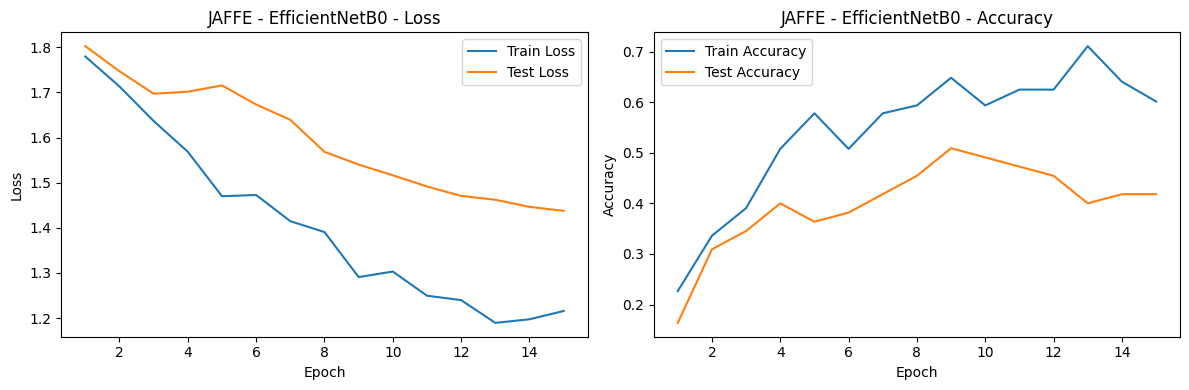

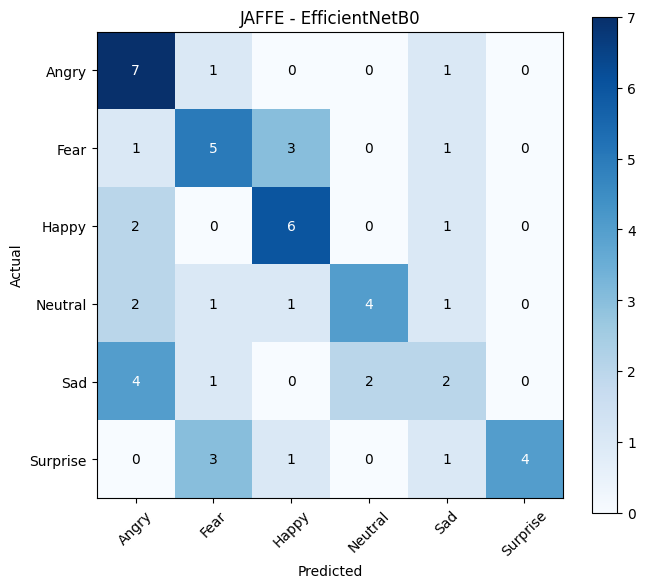

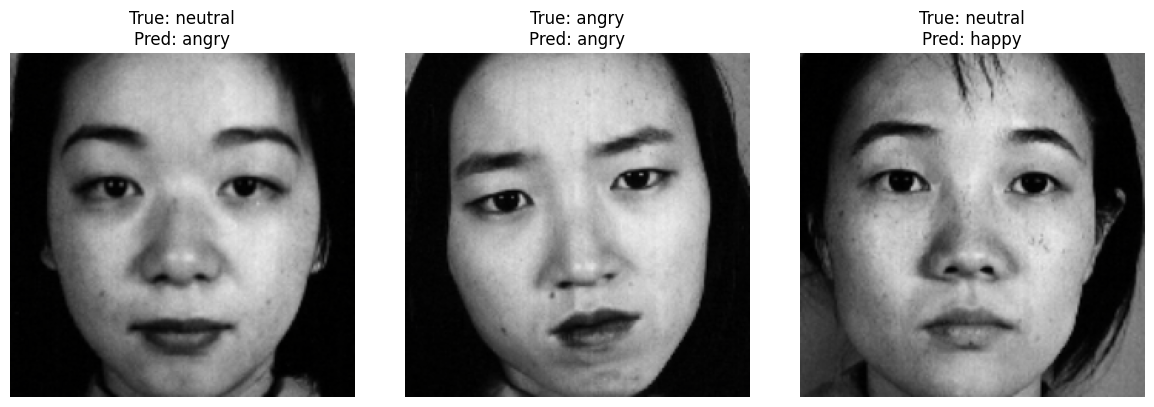

In [17]:
# JAFFE: Stage 1 - Frozen EfficientNetB0
print("\nRunning experiment on JAFFE - EfficientNetB0 (Frozen)")

jaffe_train_dataset, jaffe_test_dataset, jaffe_train_loader, jaffe_test_loader = get_dataloaders("JAFFE", batch_size=16)

jaffe_class_weights = compute_class_weights(jaffe_train_dataset)

jaffe_model = build_efficientnet_b0(num_classes=len(CLASS_NAMES), freeze_features=True).to(device)
criterion = nn.CrossEntropyLoss(weight=jaffe_class_weights)

# Only train classifier head parameters
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, jaffe_model.parameters()),
    lr=0.001
)

jaffe_model, jaffe_history = fit_model(
    jaffe_model,
    jaffe_train_loader,
    jaffe_test_loader,
    criterion,
    optimizer,
    epochs=15
)

jaffe_test_loss, jaffe_test_acc, jaffe_y_true, jaffe_y_pred = evaluate(
    jaffe_model, jaffe_test_loader, criterion
)

print("Test Accuracy:", jaffe_test_acc)
print_metrics(jaffe_y_true, jaffe_y_pred)
plot_history(jaffe_history, "JAFFE - EfficientNetB0")
plot_conf_matrix(jaffe_y_true, jaffe_y_pred, "JAFFE - EfficientNetB0")
show_sample_predictions(jaffe_model, jaffe_test_dataset)

acc, precision, recall, f1_macro, f1_weighted = get_all_metrics(jaffe_y_true, jaffe_y_pred)
results.append(["JAFFE", "EfficientNetB0", acc, precision, recall, f1_macro, f1_weighted])


Fine-tuning EfficientNetB0 on JAFFE
Epoch [1/10] Train Loss: 1.2155 | Train Acc: 0.7188 | Test Loss: 1.4173 | Test Acc: 0.4909
Epoch [2/10] Train Loss: 1.1192 | Train Acc: 0.7344 | Test Loss: 1.2860 | Test Acc: 0.5455
Epoch [3/10] Train Loss: 0.9539 | Train Acc: 0.8047 | Test Loss: 1.1375 | Test Acc: 0.6000
Epoch [4/10] Train Loss: 0.8114 | Train Acc: 0.8438 | Test Loss: 1.0131 | Test Acc: 0.6909
Epoch [5/10] Train Loss: 0.7166 | Train Acc: 0.8672 | Test Loss: 0.9029 | Test Acc: 0.6364
Epoch [6/10] Train Loss: 0.5645 | Train Acc: 0.8906 | Test Loss: 0.8857 | Test Acc: 0.6182
Epoch [7/10] Train Loss: 0.5108 | Train Acc: 0.9062 | Test Loss: 0.8326 | Test Acc: 0.6727
Epoch [8/10] Train Loss: 0.3842 | Train Acc: 0.9609 | Test Loss: 0.7672 | Test Acc: 0.7273
Epoch [9/10] Train Loss: 0.3281 | Train Acc: 0.9688 | Test Loss: 0.6819 | Test Acc: 0.7091
Epoch [10/10] Train Loss: 0.2749 | Train Acc: 0.9766 | Test Loss: 0.6442 | Test Acc: 0.7455
Fine-tuned Test Accuracy: 0.7454545454545455

Classi

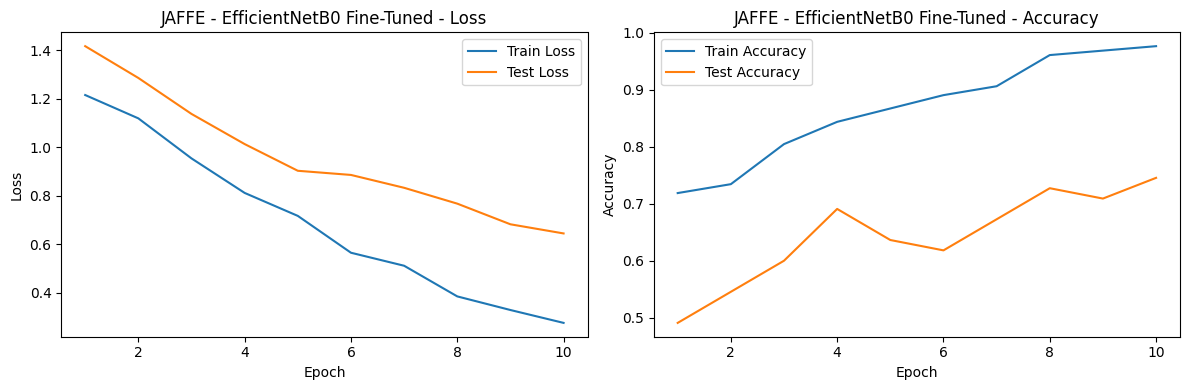

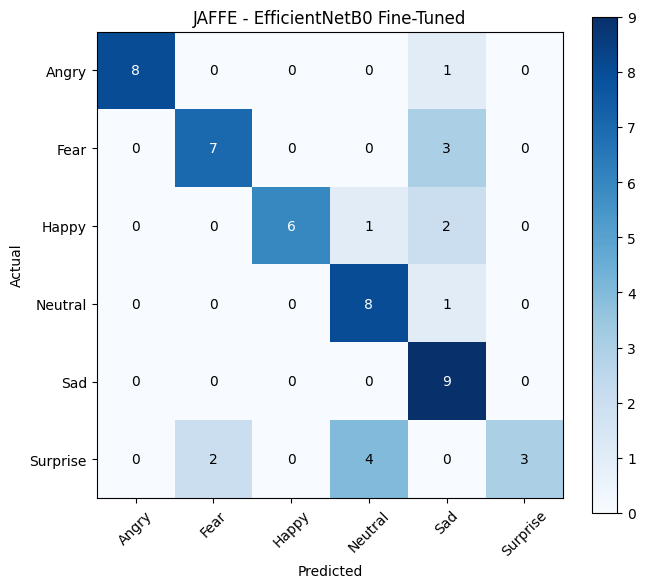

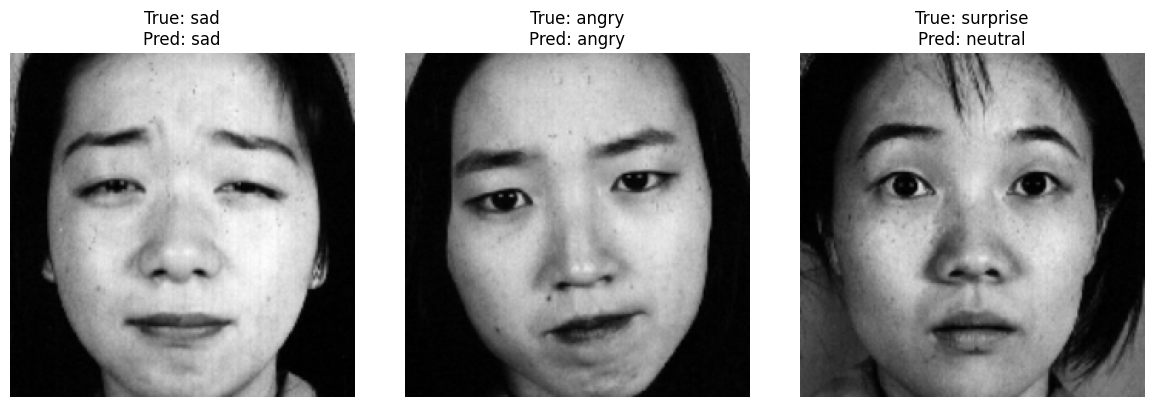

In [18]:
# JAFFE: Stage 2 - Fine-Tuned EfficientNetB0
print("\nFine-tuning EfficientNetB0 on JAFFE")

# Unfreeze all layers for fine-tuning
for param in jaffe_model.features.parameters():
    param.requires_grad = True

# Use lower learning rate to avoid overwriting pre-trained weights
optimizer_ft = optim.Adam(jaffe_model.parameters(), lr=1e-4)

jaffe_model, jaffe_ft_history = fit_model(
    jaffe_model,
    jaffe_train_loader,
    jaffe_test_loader,
    criterion,
    optimizer_ft,
    epochs=10
)

jaffe_ft_test_loss, jaffe_ft_test_acc, jaffe_ft_y_true, jaffe_ft_y_pred = evaluate(
    jaffe_model, jaffe_test_loader, criterion
)

print("Fine-tuned Test Accuracy:", jaffe_ft_test_acc)
print_metrics(jaffe_ft_y_true, jaffe_ft_y_pred)
plot_history(jaffe_ft_history, "JAFFE - EfficientNetB0 Fine-Tuned")
plot_conf_matrix(jaffe_ft_y_true, jaffe_ft_y_pred, "JAFFE - EfficientNetB0 Fine-Tuned")
show_sample_predictions(jaffe_model, jaffe_test_dataset)

acc, precision, recall, f1_macro, f1_weighted = get_all_metrics(jaffe_ft_y_true, jaffe_ft_y_pred)
results.append(["JAFFE", "EfficientNetB0 Fine-Tuned", acc, precision, recall, f1_macro, f1_weighted])


Running experiment on CK - EfficientNetB0 (Frozen)

Loaded 228 images from /content/drive/MyDrive/CK+/train
Label counts:
angry: 31
fear: 18
happy: 48
neutral: 53
sad: 20
surprise: 58

Loaded 97 images from /content/drive/MyDrive/CK+/test
Label counts:
angry: 14
fear: 7
happy: 21
neutral: 23
sad: 8
surprise: 24
Epoch [1/15] Train Loss: 1.8063 | Train Acc: 0.2237 | Test Loss: 1.7090 | Test Acc: 0.3711
Epoch [2/15] Train Loss: 1.6015 | Train Acc: 0.4737 | Test Loss: 1.6238 | Test Acc: 0.4227
Epoch [3/15] Train Loss: 1.4917 | Train Acc: 0.6096 | Test Loss: 1.5962 | Test Acc: 0.3711
Epoch [4/15] Train Loss: 1.3614 | Train Acc: 0.6711 | Test Loss: 1.4856 | Test Acc: 0.5258
Epoch [5/15] Train Loss: 1.3328 | Train Acc: 0.6491 | Test Loss: 1.4422 | Test Acc: 0.5361
Epoch [6/15] Train Loss: 1.2606 | Train Acc: 0.6491 | Test Loss: 1.4177 | Test Acc: 0.5464
Epoch [7/15] Train Loss: 1.2015 | Train Acc: 0.6535 | Test Loss: 1.3567 | Test Acc: 0.5876
Epoch [8/15] Train Loss: 1.1283 | Train Acc: 0.67

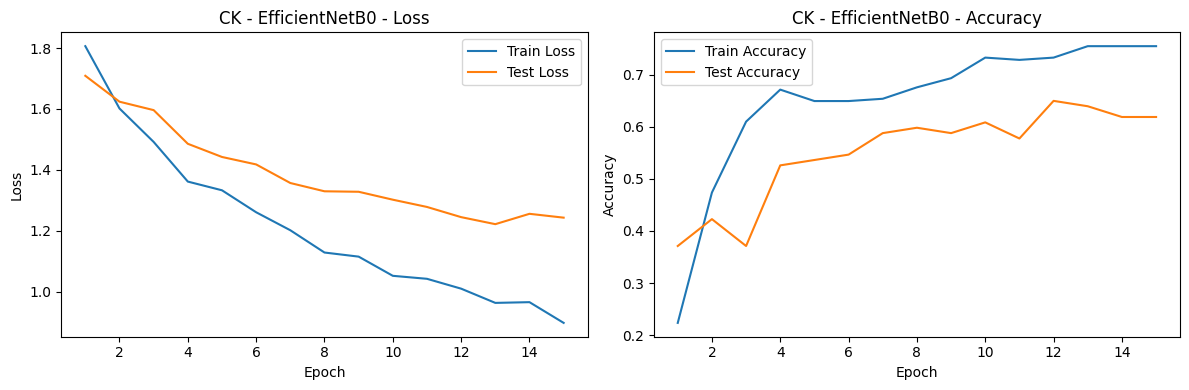

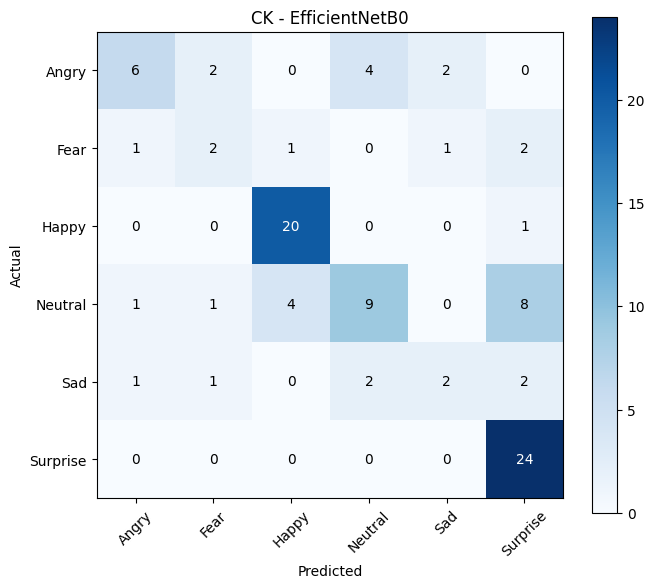

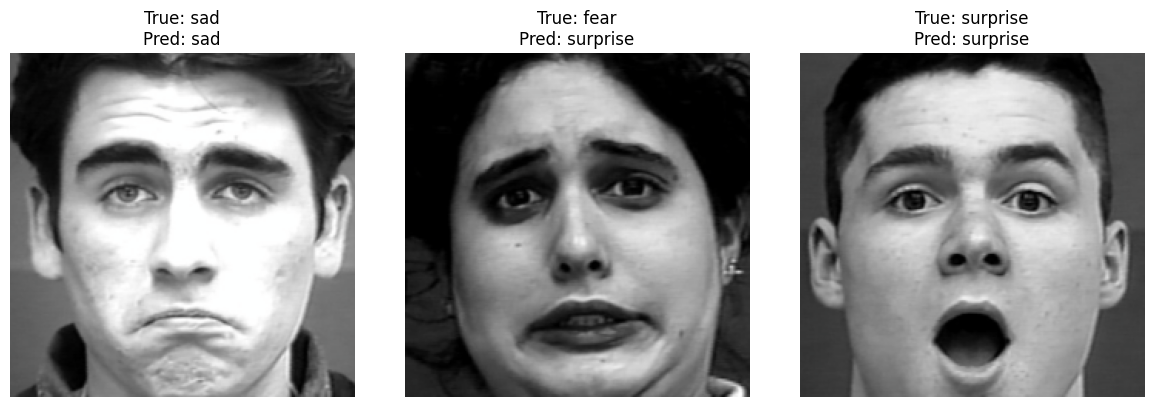

In [19]:
# CK: Stage 1 - Frozen EfficientNetB0
print("\nRunning experiment on CK - EfficientNetB0 (Frozen)")

ck_train_dataset, ck_test_dataset, ck_train_loader, ck_test_loader = get_dataloaders("CK", batch_size=16)

ck_class_weights = compute_class_weights(ck_train_dataset)

ck_model = build_efficientnet_b0(num_classes=len(CLASS_NAMES), freeze_features=True).to(device)
criterion = nn.CrossEntropyLoss(weight=ck_class_weights)

# Only train classifier head parameters
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, ck_model.parameters()),
    lr=0.001
)

ck_model, ck_history = fit_model(
    ck_model,
    ck_train_loader,
    ck_test_loader,
    criterion,
    optimizer,
    epochs=15
)

ck_test_loss, ck_test_acc, ck_y_true, ck_y_pred = evaluate(
    ck_model, ck_test_loader, criterion
)

print("Test Accuracy:", ck_test_acc)
print_metrics(ck_y_true, ck_y_pred)
plot_history(ck_history, "CK - EfficientNetB0")
plot_conf_matrix(ck_y_true, ck_y_pred, "CK - EfficientNetB0")
show_sample_predictions(ck_model, ck_test_dataset)

acc, precision, recall, f1_macro, f1_weighted = get_all_metrics(ck_y_true, ck_y_pred)
results.append(["CK", "EfficientNetB0", acc, precision, recall, f1_macro, f1_weighted])


Fine-tuning EfficientNetB0 on CK
Epoch [1/10] Train Loss: 0.8495 | Train Acc: 0.8202 | Test Loss: 0.9585 | Test Acc: 0.6701
Epoch [2/10] Train Loss: 0.6621 | Train Acc: 0.8421 | Test Loss: 0.7748 | Test Acc: 0.7423
Epoch [3/10] Train Loss: 0.4956 | Train Acc: 0.8991 | Test Loss: 0.7001 | Test Acc: 0.8247
Epoch [4/10] Train Loss: 0.3793 | Train Acc: 0.9298 | Test Loss: 0.6404 | Test Acc: 0.8351
Epoch [5/10] Train Loss: 0.3569 | Train Acc: 0.8947 | Test Loss: 0.5745 | Test Acc: 0.8351
Epoch [6/10] Train Loss: 0.2538 | Train Acc: 0.9518 | Test Loss: 0.5571 | Test Acc: 0.8454
Epoch [7/10] Train Loss: 0.1843 | Train Acc: 0.9649 | Test Loss: 0.4854 | Test Acc: 0.8866
Epoch [8/10] Train Loss: 0.1541 | Train Acc: 0.9649 | Test Loss: 0.4781 | Test Acc: 0.8763
Epoch [9/10] Train Loss: 0.1051 | Train Acc: 0.9825 | Test Loss: 0.4462 | Test Acc: 0.8866
Epoch [10/10] Train Loss: 0.0966 | Train Acc: 0.9781 | Test Loss: 0.4260 | Test Acc: 0.8660
Fine-tuned Test Accuracy: 0.8865979381443299

Classific

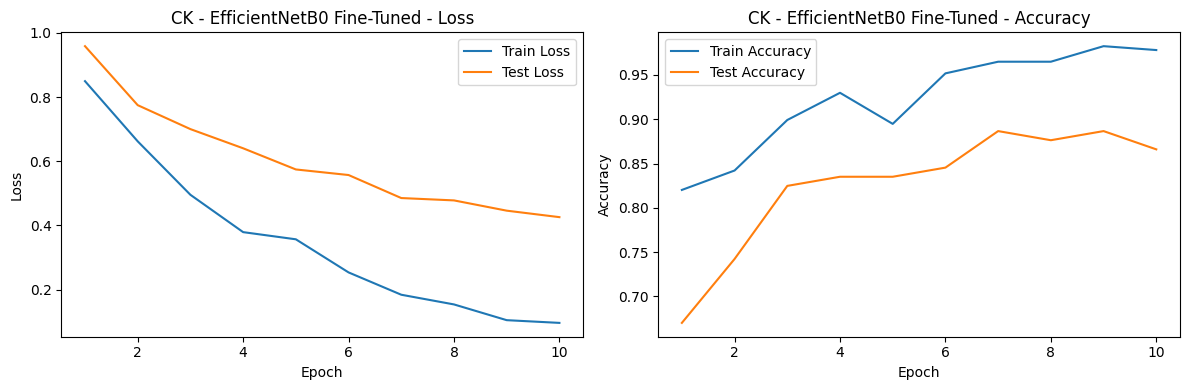

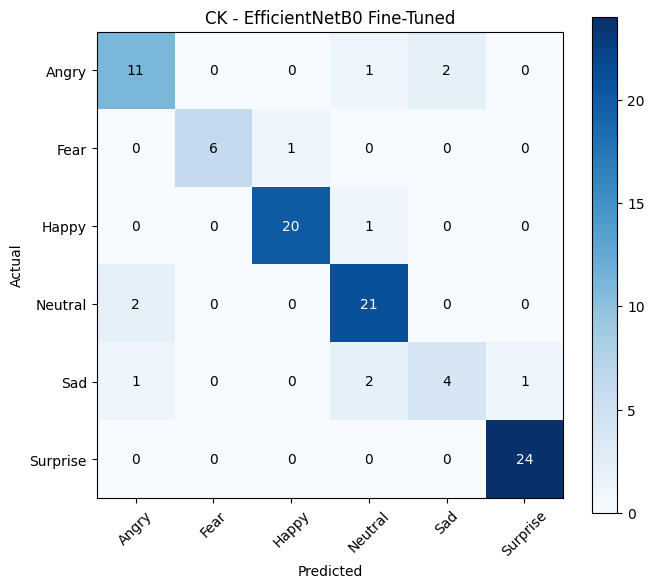

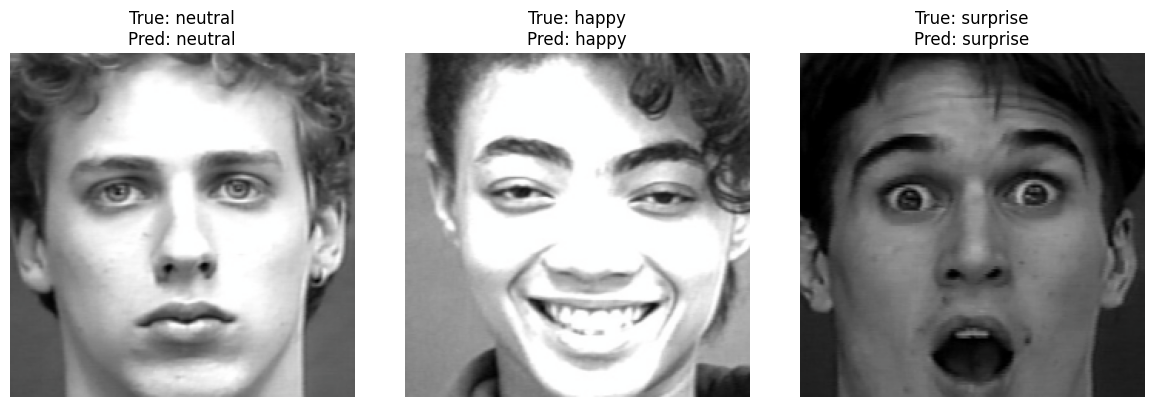

In [20]:
# CK: Stage 2 - Fine-Tuned EfficientNetB0
print("\nFine-tuning EfficientNetB0 on CK")

# Unfreeze all layers for fine-tuning
for param in ck_model.features.parameters():
    param.requires_grad = True

# Use lower learning rate to avoid overwriting pre-trained weights
optimizer_ft = optim.Adam(ck_model.parameters(), lr=1e-4)

ck_model, ck_ft_history = fit_model(
    ck_model,
    ck_train_loader,
    ck_test_loader,
    criterion,
    optimizer_ft,
    epochs=10
)

ck_ft_test_loss, ck_ft_test_acc, ck_ft_y_true, ck_ft_y_pred = evaluate(
    ck_model, ck_test_loader, criterion
)

print("Fine-tuned Test Accuracy:", ck_ft_test_acc)
print_metrics(ck_ft_y_true, ck_ft_y_pred)
plot_history(ck_ft_history, "CK - EfficientNetB0 Fine-Tuned")
plot_conf_matrix(ck_ft_y_true, ck_ft_y_pred, "CK - EfficientNetB0 Fine-Tuned")
show_sample_predictions(ck_model, ck_test_dataset)

acc, precision, recall, f1_macro, f1_weighted = get_all_metrics(ck_ft_y_true, ck_ft_y_pred)
results.append(["CK", "EfficientNetB0 Fine-Tuned", acc, precision, recall, f1_macro, f1_weighted])


Final Results
  Dataset                      Model  Accuracy  Macro Precision  Macro Recall  \
0   JAFFE             EfficientNetB0  0.509091         0.564980      0.509259   
1   JAFFE  EfficientNetB0 Fine-Tuned  0.745455         0.825944      0.746296   
2      CK             EfficientNetB0  0.649485         0.574775      0.551329   
3      CK  EfficientNetB0 Fine-Tuned  0.886598         0.867460      0.834714   

   Macro F1  Weighted F1  
0  0.505818     0.505279  
1  0.737549     0.737536  
2  0.544543     0.618150  
3  0.847865     0.883177  


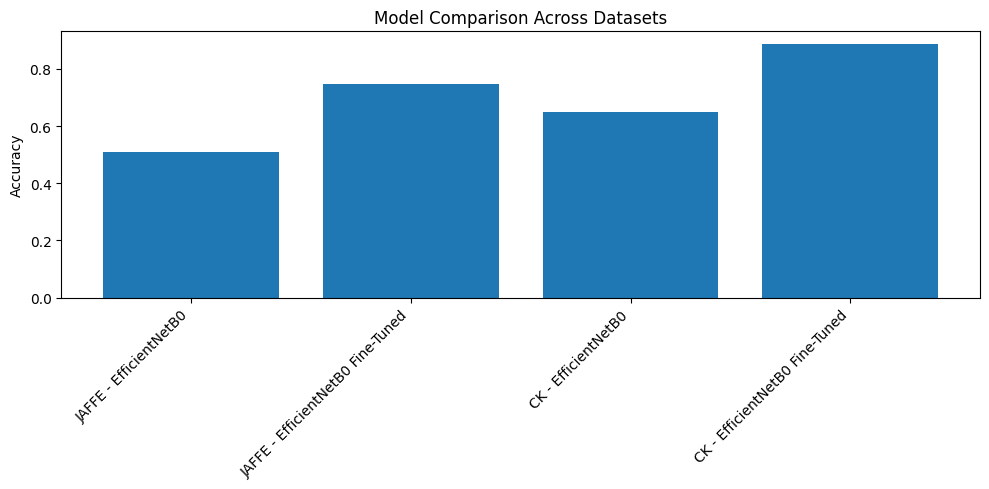

In [21]:
# Final results table
results_df = pd.DataFrame(
    results,
    columns=[
        "Dataset",
        "Model",
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ]
)

print("\nFinal Results")
print(results_df)

# Bar chart comparing accuracy across all configurations
plt.figure(figsize=(10, 5))
plt.bar(
    results_df["Dataset"] + " - " + results_df["Model"],
    results_df["Accuracy"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Comparison Across Datasets")
plt.tight_layout()
plt.show()